# Goldpreisprognose nach CRISP-DM

Dieses Notebook orchestriert ausschließlich Funktionen aus dem installierbaren Paket (`src/gold_forecasting`). Jedes Modell besitzt eine eigene Datei unter `src/gold_forecasting/models/`; das Notebook ruft pro Modell genau eine Funktion auf und enthält selbst keine Modell-, Trainings- oder Feature-Logik. Alle Abbildungen werden als PNG gespeichert und anschließend von der Festplatte angezeigt.

**Wichtig:** Trainings- und HPO-Ergebnisse werden inhaltsadressiert unter `artifacts/` zwischengespeichert und mit dem Repository versioniert (siehe `.gitignore`). Ein wiederholter Lauf mit unveränderter Konfiguration trainiert nichts neu, sondern liest die vorhandenen Ergebnisse -- das gilt insbesondere, wenn dieses Notebook auf einer anderen (z. B. schnelleren) Maschine ausgeführt und die Artefakte anschließend zurück ins Repository übernommen werden. Kapitel 7 zeigt am Ende einen Laufzeitbericht, der zwischengespeicherte von neu berechneten Schritten unterscheidet.

In [1]:
from pathlib import Path
import sys
import time
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from gold_forecasting.config import load_yaml, select_device, set_seed
from gold_forecasting.data_download import download_all
from gold_forecasting.data_preparation import prepare_dataset
from gold_forecasting.splitting import chronological_split
from gold_forecasting.plotting import plot_history, plot_chronological_split
from gold_forecasting.experiments import run_baselines, compare_results, compare_all_results, run_future

from gold_forecasting.models.sarima import run_sarima, SarimaForecaster
from gold_forecasting.models.patchtst import run_patchtst, PatchTSTForecaster
from gold_forecasting.models.chronos_zero_shot import run_chronos_original, run_chronos_bolt, ChronosForecaster
from gold_forecasting.models.sarimax import run_sarimax
from gold_forecasting.models.xgboost_model import run_xgboost
from gold_forecasting.models.tft import run_tft

RUNTIMES = []  # (name, namespace, cached, runtime_seconds) collected as we go, reported in Kapitel 7

## 1. Geschäftsverständnis

Ziel ist die Prognose des täglichen Goldpreises in USD je Feinunze. Die Prognosen unterstützen eine methodische Bewertung, sind aber keine Anlageberatung. Finanzmärkte reagieren auf Regimewechsel, Liquidität und unerwartete Ereignisse; deshalb bleiben selbst gute historische Ergebnisse unsicher. Ein Mehrwert gegenüber der naiven Persistenz und dem gleitenden Durchschnitt ist entscheidend, weil komplexe Modelle sonst keinen belegbaren Zusatznutzen liefern.

Zwei Experimente werden verglichen:

- **Experiment 1 (univariat):** SARIMA, PatchTST und Chronos (Original & Bolt, Zero-Shot) prognostizieren allein aus der Goldpreis-Historie.
- **Experiment 2 (multivariat):** SARIMAX, XGBoost und ein kompaktes, nativ implementiertes TFT nutzen zusätzlich die exogenen Reihen aus `configs/data.yaml`.

Beide Experimente werden mit rollierender Ursprungsevaluation (walk-forward) bewertet -- siehe Kapitel 3.

## 2. Datenverständnis

Yahoo Finance liefert Gold-Futures (`GC=F`) sowie optionale Reihen für US-Dollar-Index, Silber, Öl, S&P 500, VIX und Bitcoin. Unterschiedliche Handelskalender erzeugen Lücken. Der Goldpreis wird niemals über Nicht-Handelstage fortgeschrieben; exogene Reihen werden höchstens drei Ziel-Handelstage und ausschließlich aus der Vergangenheit fortgeschrieben. Das Enddatum der heruntergeladenen Daten (`configs/data.yaml: end`) ist konfigurierbar.

,gold_usd,dollar_index,silver,oil,sp500,vix,bitcoin
count,6488.000000,6488.000000,6488.000000,6488.000000,6488.000000,6488.000000,2969.000000
mean,1319.869111,92.604918,19.153107,65.042719,2389.797609,19.756117,28934.027273
std,866.655368,11.096726,12.770116,24.568320,1601.670848,8.382655,32495.904342
min,255.100006,71.330002,4.026000,-37.630001,676.530029,9.140000,178.102997
25%,656.700012,82.639999,12.358750,46.765000,1210.109985,13.980000,3486.950195
50%,1255.350037,93.269997,17.091000,64.080002,1680.549988,17.615001,11774.595703
75%,1713.950012,99.570000,23.914999,82.550003,3031.329956,23.022501,47128.003906
max,5318.399902,120.900002,115.080002,145.289993,7609.779785,82.690002,124752.531250


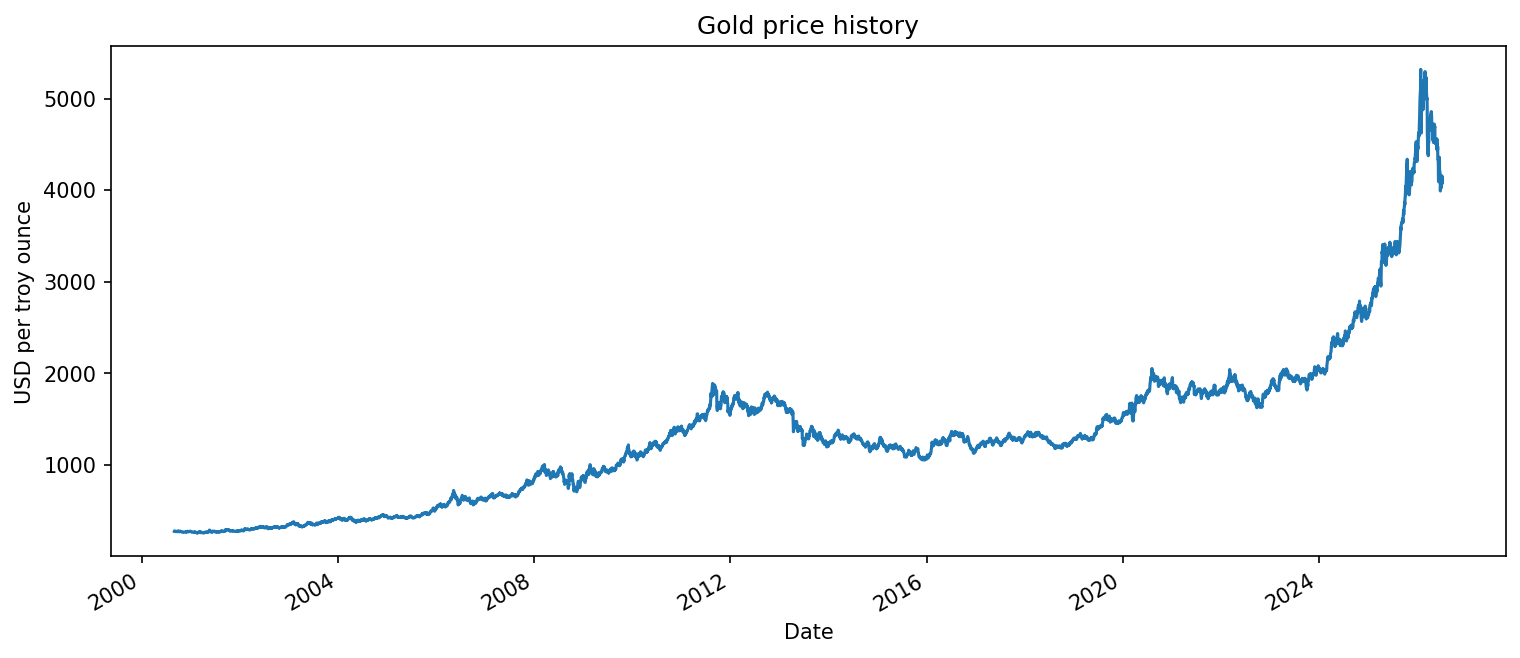

In [2]:
data_config = load_yaml('data.yaml')
raw_paths = download_all(data_config, force_download=False)
exogenous_names = list(data_config['exogenous'])
data, data_hash = prepare_dataset(raw_paths[0], dict(zip(exogenous_names, raw_paths[1:])))
display(data.describe())
display(Image(filename=str(plot_history(data['gold_usd'], data_hash))))

**Interpretation:** Die Zeitreihe zeigt Preisniveau, Schwankungsbreite und Datenabdeckung. Korrelationen sind deskriptiv und begründen keine Kausalität.

## 3. Datenvorbereitung -- Split und rollierende Ursprungsevaluation

**Konfigurierbarer, chronologischer Split:** Validierung und Test sind je `split.validation_years`/`split.test_years` Jahre lang (`configs/experiments.yaml`) und werden rückwärts vom letzten verfügbaren Datum abgeschnitten; alles davor wird zu Training. Das Enddatum der Daten (`configs/data.yaml: end`) ist ebenfalls konfigurierbar.

**Rollierende Ursprungsevaluation (walk-forward):** Statt einer einzigen langen Prognose über den gesamten Validierungs- bzw. Testzeitraum wird ein fester Prognosehorizont (`rolling.horizon`, Handelstage) wiederholt ab einem Ursprung erzeugt, der jeweils um `rolling.step` Handelstage vorrückt -- beide Werte stehen ausschließlich in `configs/experiments.yaml: rolling` (siehe Ausgabe der Zelle unten) und werden hier nur angezeigt, nicht überschrieben. Unvollständige Restfenster am Ende werden verworfen. Alle Teilprognosen werden für Diagramme und Metriken aneinandergereiht.

**Kein Leck:** Jedes Fenster erhält als Eingabe ausschließlich echte Daten, die strikt vor seinem eigenen Ursprung liegen -- niemals Daten aus dem eigenen oder einem späteren Fenster. Während der Hyperparameteroptimierung (HPO) wird dieselbe rollierende Auswertung ausschließlich über den Validierungsbereich ausgeführt; der Testbereich ist in diesem Datenrahmen strukturell gar nicht enthalten.

**Neu trainieren pro Schritt:** Jedes Modell passt sich an jedem rollierenden Fenster erneut an ("retrain_each_step", konfigurierbar je Modell in `configs/models.yaml`, Standard: `true` für alle). SARIMA, SARIMAX und XGBoost werden dabei vollständig neu geschätzt; PatchTST und TFT setzen das Training der bestehenden Gewichte fort (Warm-Start, `update_epochs`) statt neu zu initialisieren. Dieselbe Logik gilt während der HPO-Trials wie bei der finalen Testauswertung.

**Validierung wird zu Trainingsdaten:** Sobald die Hyperparameter nach der HPO eingefroren sind, wird die Validierungsmenge automatisch zu Trainingsdaten -- das erste Testfenster erhält als Eingabe genau Training+Validierung, ohne Sonderfall im Code.

**Bekannte-Exogene-Annahme (Experiment 2):** Jedes Fenster verwendet die tatsächlich realisierten exogenen Werte für die jeweils nur 20 Tage voraus -- eine deutlich lokalere und begründbarere Annahme als eine einzelne, weit vorausschauende Prognose.

mode=quick_mode (Umschalten auf 'quick_mode' fuer einen schnellen Testlauf: configs/experiments.yaml: mode)
hpo: n_trials=3  epochs=3  patience=2  update_epochs=1  seed=42
rolling (configs/experiments.yaml: rolling): horizon=20 Tage  step=20 Tage  lead_time_checkpoints=(1, 10, 20)
split (configs/experiments.yaml: split): validation=1y  test=1y

Je Modell konfiguriertes enabled / retrain_each_step (configs/models.yaml) -- enabled=false ueberspringt ein Modell vollstaendig, ohne dass Vergleiche/Diagramme danach fehlschlagen:
  sarima: enabled=True  retrain_each_step=True
  patchtst: enabled=True  retrain_each_step=True
  sarimax: enabled=True  retrain_each_step=True
  xgboost: enabled=True  retrain_each_step=True
  tft: enabled=True  retrain_each_step=True
  chronos_original: enabled=True
  chronos_bolt: enabled=True

train=2000-08-30..2024-07-10 (5985 rows)
validation=2024-07-11..2025-07-10 (252 rows)
test=2025-07-11..2026-07-10 (251 rows)


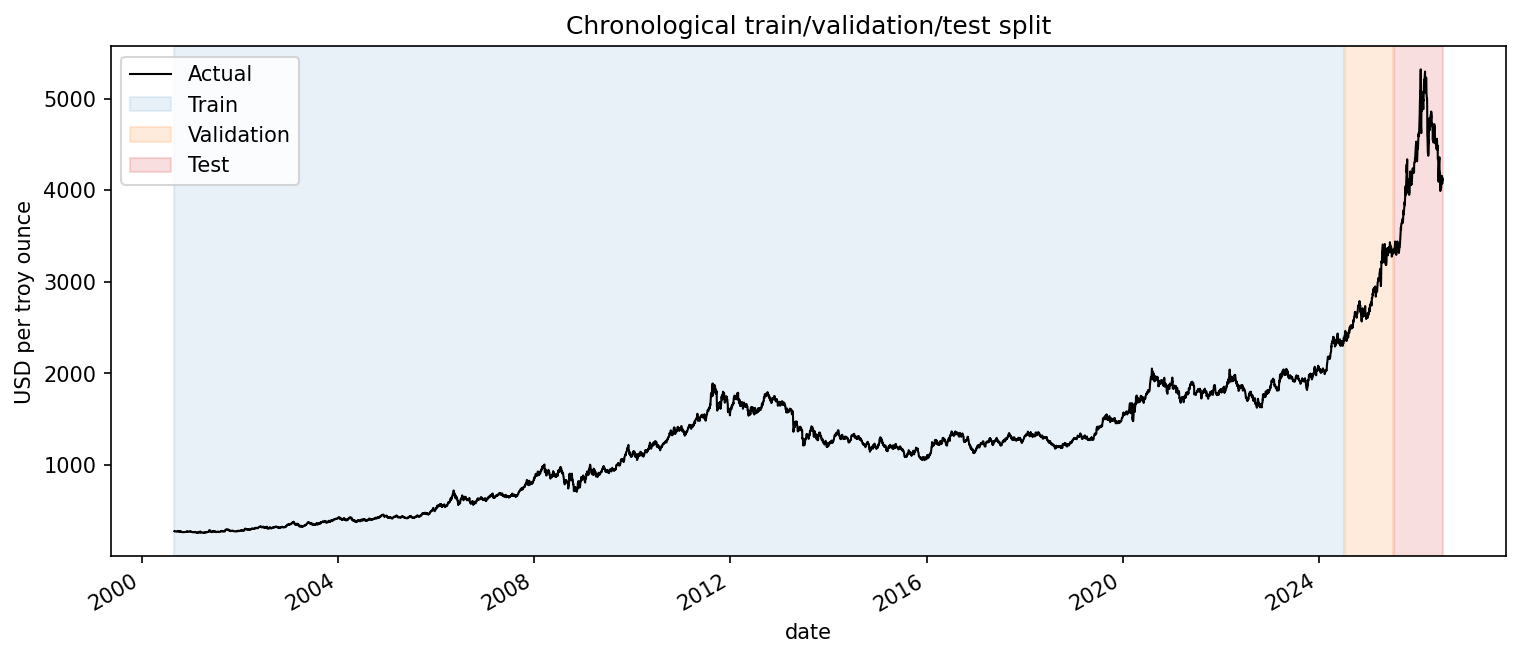

In [3]:
experiment_config = load_yaml('experiments.yaml')
models_config = load_yaml('models.yaml')
mode = experiment_config['mode']
hpo = models_config['hpo'][mode]
seed = int(models_config['seed'])
set_seed(seed)
device = select_device()
horizon = experiment_config['rolling']['horizon']
step = experiment_config['rolling']['step']
lead_time_checkpoints = tuple(experiment_config['lead_time_checkpoints'])

# Univariate split (Experiment 1): target only.
split_uni = chronological_split(data[['gold_usd']], **experiment_config['split'])
# Multivariate split (Experiment 2): target + exogenous columns, same boundaries.
multivariate_columns = ['gold_usd', *exogenous_names]
split_multi = chronological_split(data[multivariate_columns].dropna(), **experiment_config['split'])

print(f"mode={mode} (Umschalten auf 'quick_mode' fuer einen schnellen Testlauf: configs/experiments.yaml: mode)")
print(f"hpo: n_trials={hpo['n_trials']}  epochs={hpo['epochs']}  patience={hpo['patience']}  update_epochs={hpo['update_epochs']}  seed={seed}")
print(f"rolling (configs/experiments.yaml: rolling): horizon={horizon} Tage  step={step} Tage  lead_time_checkpoints={lead_time_checkpoints}")
print(f"split (configs/experiments.yaml: split): validation={experiment_config['split']['validation_years']}y  test={experiment_config['split']['test_years']}y")
print()
print('Je Modell konfiguriertes enabled / retrain_each_step (configs/models.yaml) -- enabled=false ueberspringt ein Modell vollstaendig, ohne dass Vergleiche/Diagramme danach fehlschlagen:')
for name in ['sarima', 'patchtst', 'sarimax', 'xgboost', 'tft']:
    print(f"  {name}: enabled={models_config[name].get('enabled', True)}  retrain_each_step={models_config[name].get('retrain_each_step', True)}")
print(f"  chronos_original: enabled={models_config['chronos'].get('enabled_original', True)}")
print(f"  chronos_bolt: enabled={models_config['chronos'].get('enabled_bolt', True)}")
print()
print(f"train={split_uni.train.index.min().date()}..{split_uni.train.index.max().date()} ({len(split_uni.train)} rows)")
print(f"validation={split_uni.validation.index.min().date()}..{split_uni.validation.index.max().date()} ({len(split_uni.validation)} rows)")
print(f"test={split_uni.test.index.min().date()}..{split_uni.test.index.max().date()} ({len(split_uni.test)} rows)")
display(Image(filename=str(plot_chronological_split(data['gold_usd'], split_uni, data_hash))))

## 4. Modellierung

Verglichen werden zwei Experimente. Alle Modelle sind entweder nativ in PyTorch implementiert (PatchTST, TFT) oder verwenden etablierte Bibliotheken (statsmodels, XGBoost, Chronos). Hyperparameteroptimierung läuft über Optuna-Studien, die in `artifacts/optuna/*.db` gespeichert werden: wird ein Lauf unterbrochen, führt der nächste Aufruf nur die noch fehlenden Trials aus. Die vollständige Trial-Historie (alle Hyperparameter-Kombinationen und ihr Zielwert) wird zusätzlich menschenlesbar unter `artifacts/hpo_trials/` gespeichert -- ohne dass dafür die MLflow-Oberfläche gestartet werden muss.

### 4.1 Experiment 1: Univariate Prognose (ohne exogene Variablen)

- **SARIMA:** Optuna durchsucht (p, d, q) auf Basis des rollierenden Validierungsfehlers; keine Skalierung nötig, da statsmodels direkt auf USD-Preisen arbeitet.
- **PatchTST:** Architektur- und Optimierungs-Hyperparameter werden per Optuna gesucht; die Zielreihe wird mit einem ausschließlich auf verfügbaren Trainingsdaten angepassten `StandardScaler` skaliert.
- **Chronos (Original & Bolt):** vortrainierte Zero-Shot-Modelle von Amazon -- kein Training, keine Hyperparameteroptimierung. Chronos normalisiert seinen Eingabekontext intern; keine externe Skalierung nötig.

In [4]:
if models_config['sarima'].get('enabled', True):
    sarima_result = run_sarima(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                models_config['sarima'], hpo, data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('sarima', 'univariate', sarima_result['cached'], sarima_result['runtime_seconds']))
    print('SARIMA best params:', sarima_result['best_params'])
else:
    sarima_result = None
    print('SARIMA deaktiviert (configs/models.yaml: sarima.enabled=false)')

SARIMA best params: {'order': [2, 0, 0], 'seasonal_order': [0, 0, 0, 0]}


In [5]:
if models_config['patchtst'].get('enabled', True):
    patchtst_result = run_patchtst(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                    models_config['patchtst'], hpo, data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('patchtst', 'univariate', patchtst_result['cached'], patchtst_result['runtime_seconds']))
else:
    patchtst_result = None
    print('PatchTST deaktiviert (configs/models.yaml: patchtst.enabled=false)')

In [6]:
if models_config['chronos'].get('enabled_original', True):
    chronos_original_result = run_chronos_original(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                                    models_config['chronos'], data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('chronos_original', 'univariate', chronos_original_result['cached'], chronos_original_result['runtime_seconds']))
else:
    chronos_original_result = None
    print('Chronos (Original) deaktiviert (configs/models.yaml: chronos.enabled_original=false)')

if models_config['chronos'].get('enabled_bolt', True):
    chronos_bolt_result = run_chronos_bolt(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                            models_config['chronos'], data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('chronos_bolt', 'univariate', chronos_bolt_result['cached'], chronos_bolt_result['runtime_seconds']))
else:
    chronos_bolt_result = None
    print('Chronos (Bolt) deaktiviert (configs/models.yaml: chronos.enabled_bolt=false)')

In [7]:
univariate_baselines = run_baselines(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                      'univariate', data_hash, seed, {'lead_time_checkpoints': lead_time_checkpoints}, horizon, step,
                                      moving_average_window=experiment_config['moving_average_window'],
                                      enabled={'naive': models_config['naive'].get('enabled', True), 'moving_average': models_config['moving_average'].get('enabled', True)})
for name, r in univariate_baselines.items(): RUNTIMES.append((name, 'univariate', r['cached'], r['runtime_seconds']))

,model,horizon,mae,rmse,mase,smape,directional_accuracy
8,chronos_original,1,88.747778,192.333154,10.296680,1.901364,1.000000
16,naive,1,93.708313,181.149311,10.872211,2.037336,1.000000
0,sarima,1,94.369411,182.664355,10.948913,2.048380,1.000000
12,chronos_bolt,1,109.894265,221.731967,12.750135,2.346365,1.000000
20,moving_average,1,138.913765,177.781385,16.117031,3.251799,0.818182
4,patchtst,1,311.186595,331.837743,36.104441,7.345326,0.363636
9,chronos_original,10,160.235722,213.915277,18.590843,3.532877,0.909091
1,sarima,10,164.541629,209.145416,19.090422,3.670018,0.909091
17,naive,10,168.350016,203.503369,19.532279,3.802773,0.909091
21,moving_average,10,172.574603,225.354064,20.022423,4.100541,1.000000


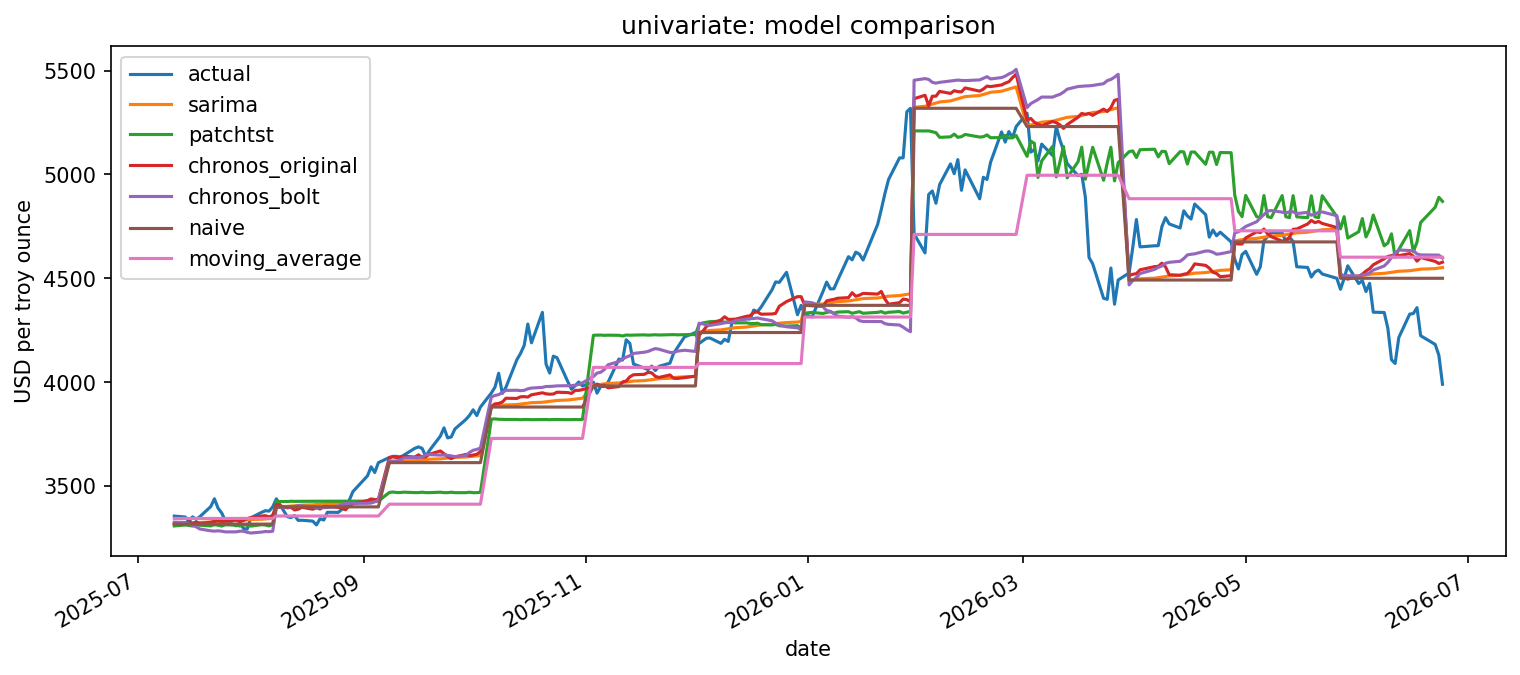

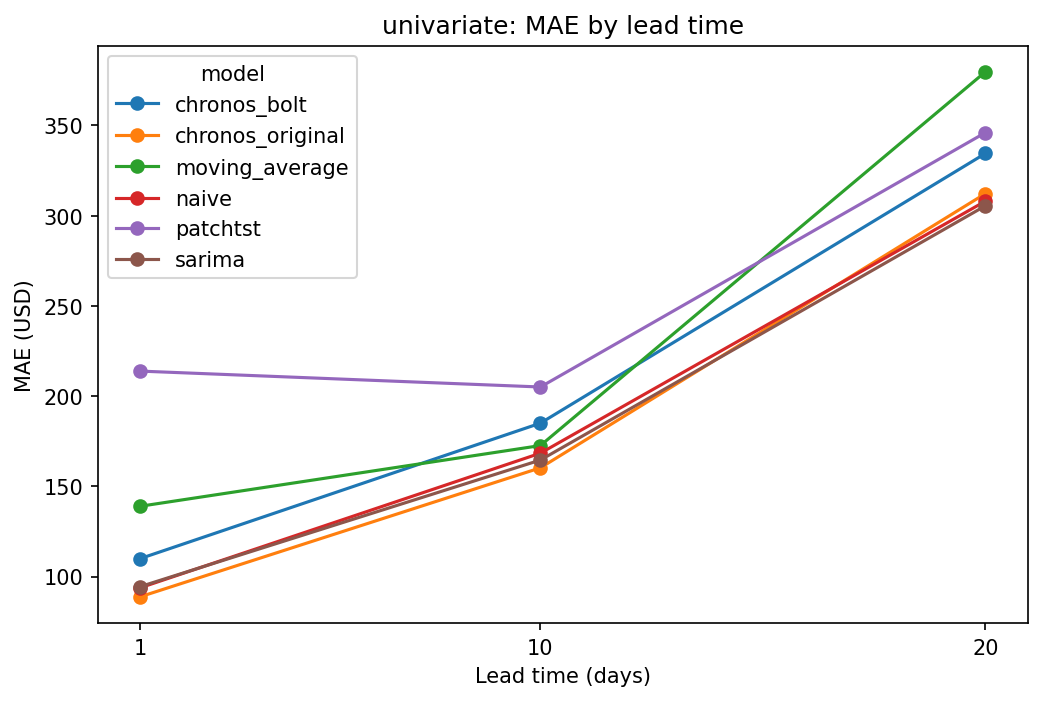

In [8]:
univariate_results = {name: r for name, r in {
    'sarima': sarima_result, 'patchtst': patchtst_result,
    'chronos_original': chronos_original_result, 'chronos_bolt': chronos_bolt_result,
    **univariate_baselines,
}.items() if r is not None}  # disabled models (enabled=false) are None and dropped here, so downstream comparisons never see them
univariate_metrics, univariate_plot, univariate_lead_time_plot = compare_results(univariate_results, 'univariate', data_hash)
display(univariate_metrics)
display(Image(filename=str(univariate_plot)))
display(Image(filename=str(univariate_lead_time_plot)))

### 4.2 Experiment 2: Multivariate Prognose (mit exogenen Variablen)

Exogene Variablen stammen aus `configs/data.yaml: exogenous` (US-Dollar-Index, Silber, Öl, S&P 500, VIX, Bitcoin).

- **SARIMAX:** Optuna durchsucht (p, d, q); exogene Regressoren werden mit einem `StandardScaler` skaliert (Konditionierung der Koeffizienten), die Zielgröße bleibt unskaliert.
- **XGBoost:** Lag-, Rolling- und exogene Features (`feature_engineering.create_features`); keine Skalierung nötig, da baumbasierte Modelle skaleninvariant sind.
- **TFT (kompakt, nativ):** Variable-Selection-Gating, LSTM-Encoder und ein Multi-Head-Attention-Block -- eine schlanke, nativ in PyTorch implementierte Annäherung an den Temporal Fusion Transformer.

In [9]:
if models_config['sarimax'].get('enabled', True):
    sarimax_result = run_sarimax(split_multi.train, split_multi.validation, split_multi.test,
                                  models_config['sarimax'], hpo, data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('sarimax', 'multivariate', sarimax_result['cached'], sarimax_result['runtime_seconds']))
    print('SARIMAX best params:', sarimax_result['best_params'])
else:
    sarimax_result = None
    print('SARIMAX deaktiviert (configs/models.yaml: sarimax.enabled=false)')

SARIMAX best params: {'order': [1, 2, 2], 'seasonal_order': [0, 0, 0, 0]}


In [10]:
if models_config['xgboost'].get('enabled', True):
    xgboost_result = run_xgboost(split_multi.train, split_multi.validation, split_multi.test,
                                  models_config['xgboost'], hpo, data_config['features'], data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('xgboost', 'multivariate', xgboost_result['cached'], xgboost_result['runtime_seconds']))
    print('XGBoost best params:', xgboost_result['best_params'])
else:
    xgboost_result = None
    print('XGBoost deaktiviert (configs/models.yaml: xgboost.enabled=false)')

XGBoost best params: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 466, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}


In [11]:
if models_config['tft'].get('enabled', True):
    tft_result = run_tft(split_multi.train, split_multi.validation, split_multi.test,
                          models_config['tft'], hpo, data_hash, seed, horizon, step, lead_time_checkpoints=lead_time_checkpoints)
    RUNTIMES.append(('tft', 'multivariate', tft_result['cached'], tft_result['runtime_seconds']))
else:
    tft_result = None
    print('TFT deaktiviert (configs/models.yaml: tft.enabled=false)')

In [12]:
multivariate_baselines = run_baselines(split_multi.train.gold_usd, split_multi.validation.gold_usd, split_multi.test.gold_usd,
                                        'multivariate', data_hash, seed, {'lead_time_checkpoints': lead_time_checkpoints}, horizon, step,
                                        moving_average_window=experiment_config['moving_average_window'],
                                        enabled={'naive': models_config['naive'].get('enabled', True), 'moving_average': models_config['moving_average'].get('enabled', True)})
for name, r in multivariate_baselines.items(): RUNTIMES.append((name, 'multivariate', r['cached'], r['runtime_seconds']))

,model,horizon,mae,rmse,mase,smape,directional_accuracy
0,sarimax,1,49.151186,64.977296,4.730948,1.119281,1.000000
12,naive,1,93.708313,181.149311,9.019704,2.037336,1.000000
4,xgboost,1,115.466471,163.285175,11.113992,2.609525,0.818182
16,moving_average,1,138.913765,177.781385,13.370864,3.251799,0.818182
8,tft,1,215.111862,284.128224,20.705157,4.977014,0.545455
1,sarimax,10,98.031358,131.506896,9.435810,2.219712,0.818182
13,naive,10,168.350016,203.503369,16.204190,3.802773,0.909091
17,moving_average,10,172.574603,225.354064,16.610819,4.100541,1.000000
5,xgboost,10,177.618429,267.156357,17.096303,4.192821,0.727273
9,tft,10,279.981717,345.354233,26.949074,6.484528,0.454545


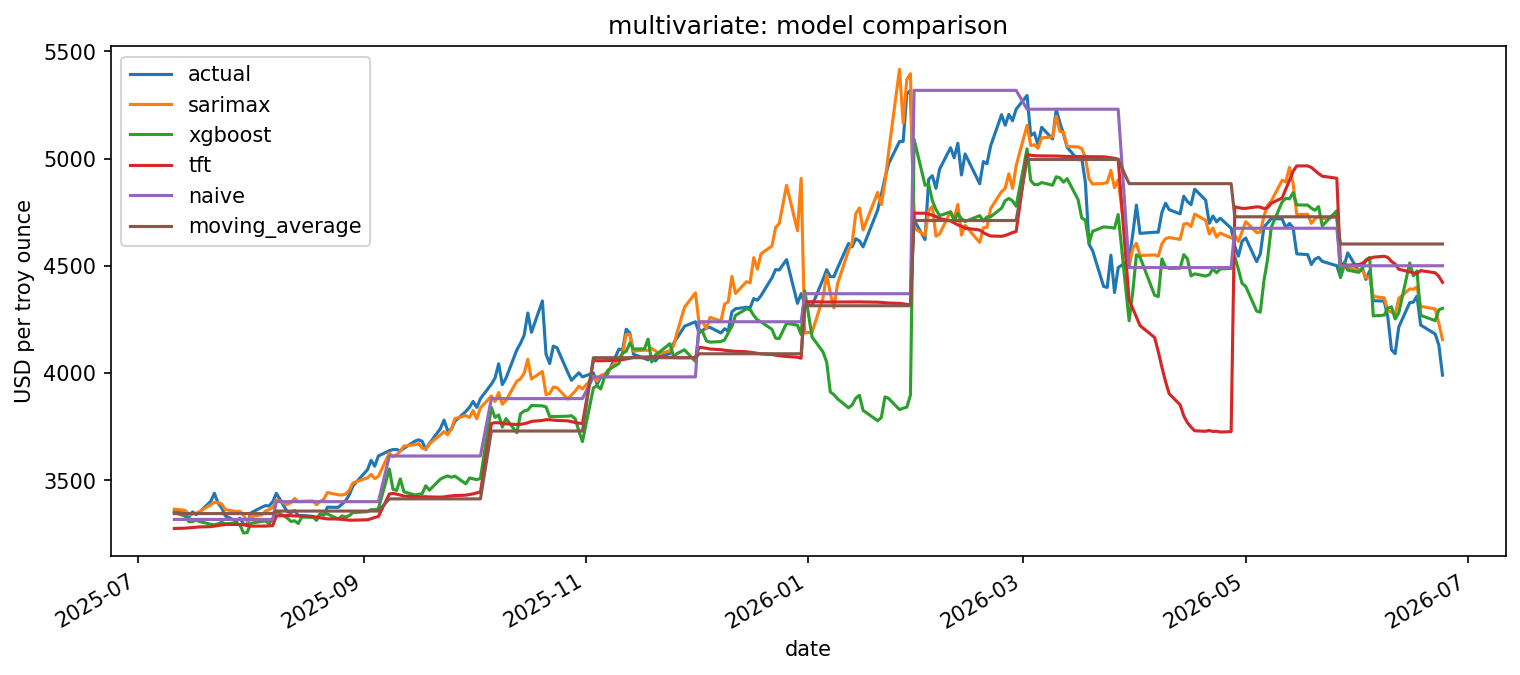

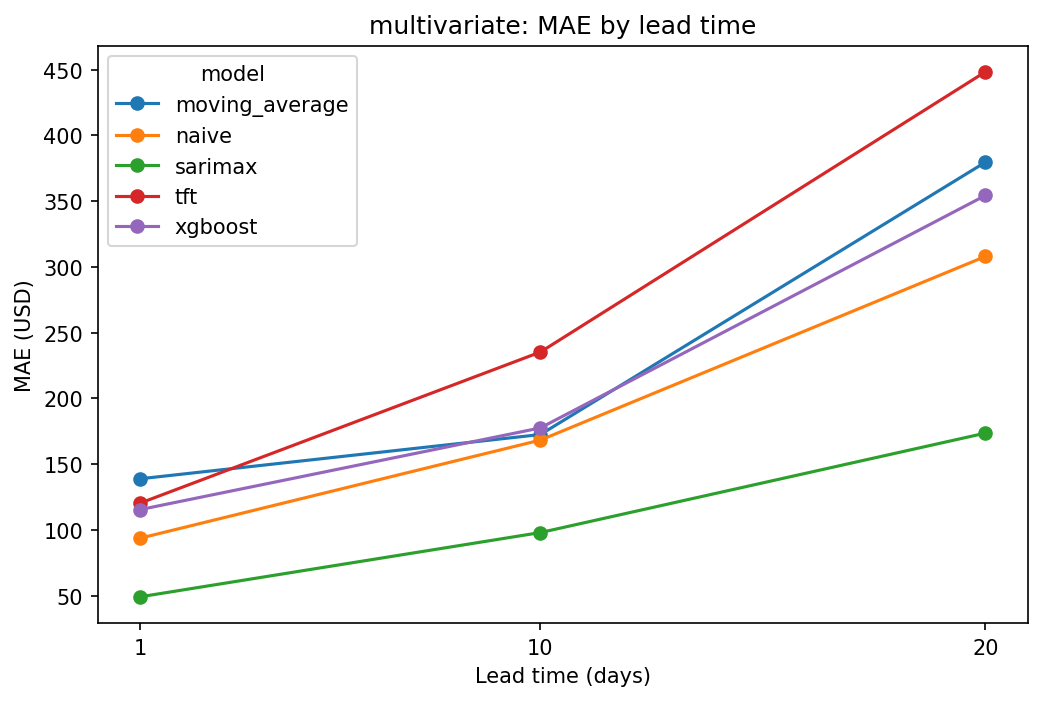

In [13]:
multivariate_results = {name: r for name, r in {
    'sarimax': sarimax_result, 'xgboost': xgboost_result, 'tft': tft_result,
    **multivariate_baselines,
}.items() if r is not None}
multivariate_metrics, multivariate_plot, multivariate_lead_time_plot = compare_results(multivariate_results, 'multivariate', data_hash)
display(multivariate_metrics)
display(Image(filename=str(multivariate_plot)))
display(Image(filename=str(multivariate_lead_time_plot)))

## 5. Evaluation

Beim strikt eingefrorenen Ursprung enden Training, Skalierung, Validierung und Modellwahl vor dem Testzeitraum. Während der gesamten maskierten Periode werden keine echten Goldpreise als neue Eingaben verwendet -- mit der in Kapitel 3/4.2 dokumentierten, expliziten und lokal begrenzten Ausnahme der exogenen Regressoren in Experiment 2. MAE, RMSE, MASE, sMAPE und Richtungsgenauigkeit werden für die Lead-Time-Stützstellen (Tag 1, 10, 20 -- Teilmengen desselben 20-Tage-Fensters, nie ein anderer Horizont) sowie für den vollständigen rollierenden Testzeitraum berichtet.

**Modellvergleich über alle sechs Modelle beider Experimente hinweg** (dieselbe Zielreihe, derselbe Testzeitraum):

,model,horizon,mae,rmse,mase,smape,directional_accuracy
24,sarimax,1,49.151186,64.977296,4.730948,1.119281,1.000000
8,chronos_original,1,88.747778,192.333154,10.296680,1.901364,1.000000
16,naive,1,93.708313,181.149311,9.019704,2.037336,1.000000
0,sarima,1,94.369411,182.664355,10.948913,2.048380,1.000000
12,chronos_bolt,1,109.894265,221.731967,12.750135,2.346365,1.000000
28,xgboost,1,115.466471,163.285175,11.113992,2.609525,0.818182
20,moving_average,1,138.913765,177.781385,13.370864,3.251799,0.818182
32,tft,1,215.111862,284.128224,20.705157,4.977014,0.545455
4,patchtst,1,311.186595,331.837743,36.104441,7.345326,0.363636
25,sarimax,10,98.031358,131.506896,9.435810,2.219712,0.818182


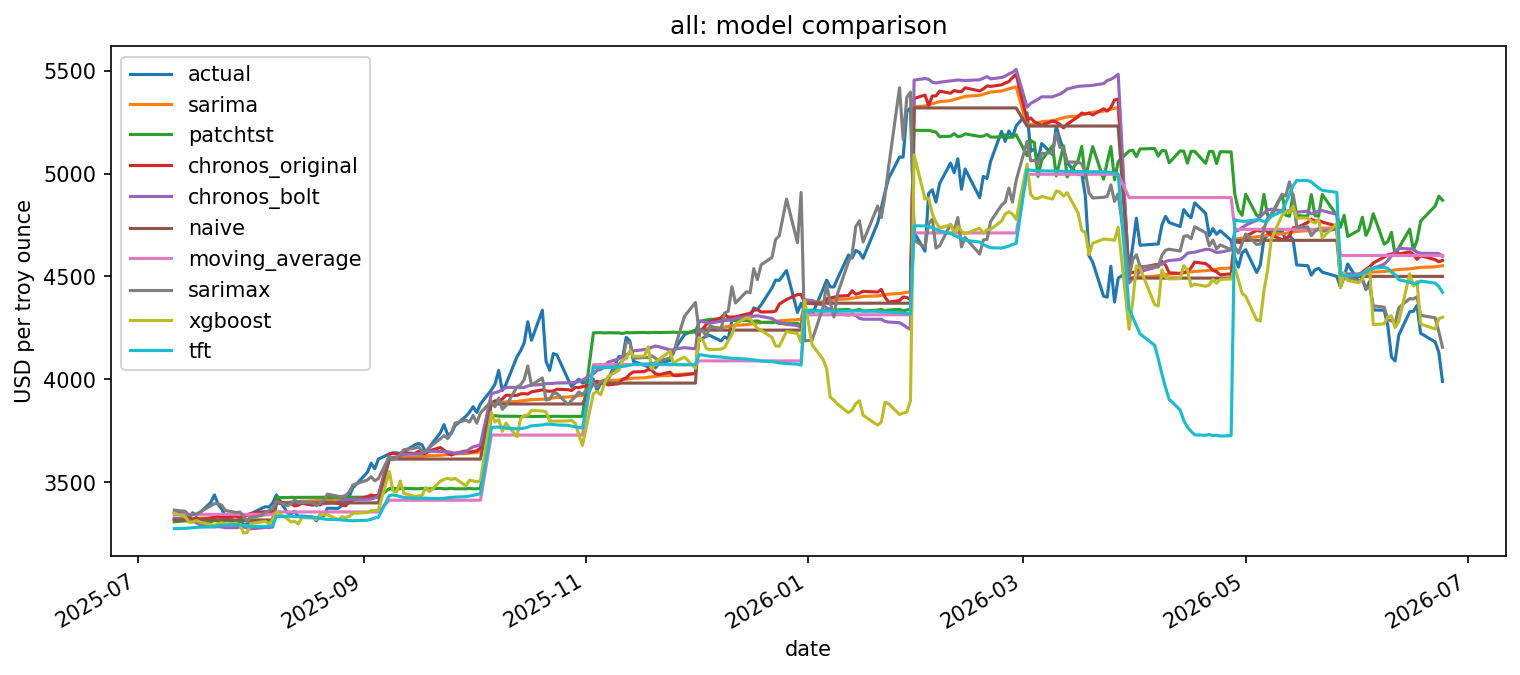

In [14]:
all_metrics, all_plot = compare_all_results(univariate_results, multivariate_results, data_hash)
display(all_metrics)
display(Image(filename=str(all_plot)))

**Interpretation:** Niedrigere Fehler sind besser; Richtungsgenauigkeit muss im Kontext betrachtet werden. Ein komplexes Modell überzeugt nur, wenn es Naiv und gleitenden Durchschnitt robust schlägt (MASE < 1). Die MAE-nach-Lead-Time-Diagramme (Kapitel 4.1/4.2) zeigen, wie stark die Fehler vom ersten zum zwanzigsten Prognosetag innerhalb desselben rollierenden Fensters zunehmen.

## 6. Bereitstellung

Für eine echte Zukunftsprognose (Daten jenseits des heruntergeladenen Enddatums) werden ausschließlich die univariaten Modelle aus Experiment 1 verwendet: Für SARIMAX, XGBoost und TFT müssten die exogenen Variablen selbst prognostiziert werden, was hier bewusst außerhalb des Projektumfangs bleibt. Jedes Modell wird mit der gesamten verfügbaren Historie neu angepasst -- unter Wiederverwendung der Standardkonfiguration aus `configs/models.yaml` (`fallback`), ohne erneute Hyperparametersuche, um die Bereitstellung schnell zu halten. Dies ist eine einmalige Prognose, keine rollierende Auswertung -- es gibt keine echten zukünftigen Daten, gegen die man rollieren könnte. Zukunftsprognosen sind modellbasierte Szenarien mit erheblicher Unsicherheit und ausdrücklich keine Anlageberatung.

,sarima,patchtst,chronos_original,chronos_bolt
date,,,,
2026-07-13,4109.386672,4393.3130,4098.298450,4131.185927
2026-07-14,4112.998636,4379.8027,4087.945825,4131.525581
2026-07-15,4110.715999,4376.9385,4107.356555,4138.679579
2026-07-16,4112.378486,4382.7510,4131.943591,4149.615262
2026-07-17,4111.254062,4378.5146,4133.237927,4164.861382
2026-07-20,4112.044015,4370.6350,4150.060999,4165.637126
2026-07-21,4111.499850,4368.1226,4124.179529,4164.758436
2026-07-22,4111.878521,4367.4595,4126.767224,4169.980577
2026-07-23,4111.616389,4367.4014,4134.531580,4170.148492


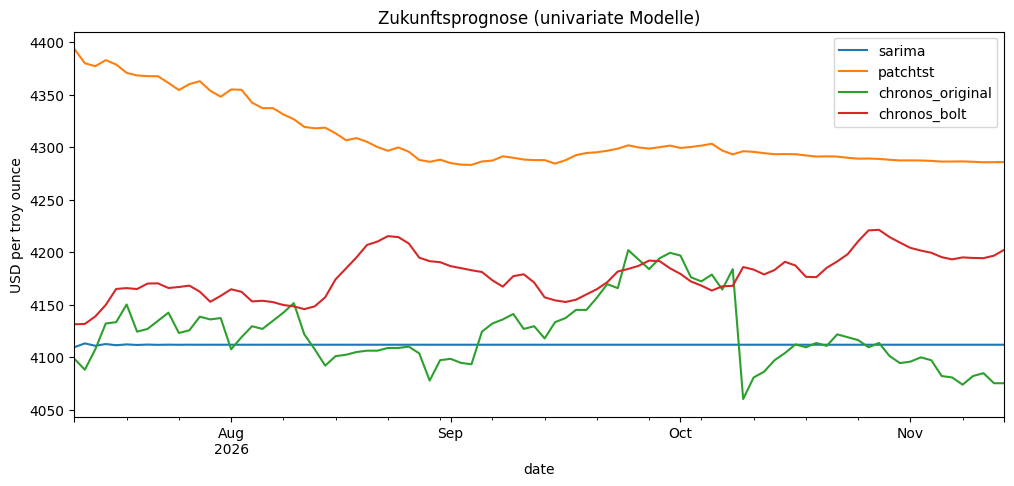

In [15]:
future_horizon = max(experiment_config['future_horizons'])
full_series = data['gold_usd'].dropna()

future_model_builders = {
    'sarima': (models_config['sarima'].get('enabled', True), lambda: SarimaForecaster(config={'order': models_config['sarima']['fallback']['order'], 'seasonal_period': models_config['sarima'].get('seasonal_period', 0), 'retrain_each_step': False})),
    'patchtst': (models_config['patchtst'].get('enabled', True), lambda: PatchTSTForecaster(config={'context_length': models_config['patchtst']['context_length'], **models_config['patchtst']['fallback'], 'epochs': hpo['epochs'], 'patience': hpo['patience'], 'retrain_each_step': False}, device=device, seed=seed)),
    'chronos_original': (models_config['chronos'].get('enabled_original', True), lambda: ChronosForecaster(config={'model_id': models_config['chronos']['variants']['original'], 'context_length': models_config['chronos'].get('context_length', 512)}, device=device)),
    'chronos_bolt': (models_config['chronos'].get('enabled_bolt', True), lambda: ChronosForecaster(config={'model_id': models_config['chronos']['variants']['bolt'], 'context_length': models_config['chronos'].get('context_length', 512)}, device=device)),
}
future_forecasts = {}
for name, (is_enabled, build) in future_model_builders.items():
    if not is_enabled:
        print(f'{name} deaktiviert -- keine Zukunftsprognose (configs/models.yaml)')
        continue
    future_forecasts[name] = run_future(build(), name, full_series, future_horizon, data_hash, seed, {'approach': 'univariate-future'})

if future_forecasts:
    future_combined = pd.concat({name: frame['predicted'] for name, frame in future_forecasts.items()}, axis=1)
    display(future_combined.head(30))
    future_combined.plot(figsize=(12, 5), title='Zukunftsprognose (univariate Modelle)', ylabel='USD per troy ounce')
else:
    print('Alle univariaten Modelle deaktiviert -- keine Zukunftsprognose moeglich.')

**Interpretation:** Unterschiede zwischen Modellen verdeutlichen Modellunsicherheit. Nicht abgebildet sind verlässliche Konfidenzintervalle, Transaktionskosten, strukturelle Brüche und extreme Ereignisse. Entscheidungen dürfen nicht allein auf diesen Punktprognosen beruhen.

## 7. Laufzeitbericht

Wie lange hat jeder Schritt gedauert -- oder wurde er aus dem Cache gelesen? Wichtig, um die Kosten eines vollständigen Neulaufs (z. B. auf einer anderen Maschine) einschätzen zu können.

In [16]:
runtime_report = pd.DataFrame(RUNTIMES, columns=['model', 'namespace', 'cached', 'runtime_seconds'])
runtime_report['status'] = runtime_report['cached'].map({True: 'aus Cache gelesen', False: 'neu berechnet'})
display(runtime_report[['namespace', 'model', 'status', 'runtime_seconds']])
print(f"Gesamtlaufzeit neu berechneter Schritte: {runtime_report.loc[~runtime_report['cached'], 'runtime_seconds'].sum():.1f} Sekunden")
print(f"Anzahl aus Cache gelesener Schritte: {int(runtime_report['cached'].sum())} von {len(runtime_report)}")

,namespace,model,status,runtime_seconds
0,univariate,sarima,aus Cache gelesen,3.711797
1,univariate,patchtst,aus Cache gelesen,20.589489
2,univariate,chronos_original,aus Cache gelesen,28.157935
3,univariate,chronos_bolt,aus Cache gelesen,1.903385
4,univariate,naive,aus Cache gelesen,0.008611
5,univariate,moving_average,aus Cache gelesen,0.009896
6,multivariate,sarimax,aus Cache gelesen,41.270392
7,multivariate,xgboost,aus Cache gelesen,18.944608
8,multivariate,tft,aus Cache gelesen,66.078405
9,multivariate,naive,aus Cache gelesen,0.006638


Gesamtlaufzeit neu berechneter Schritte: 0.0 Sekunden
Anzahl aus Cache gelesener Schritte: 11 von 11
